# Regularized Regression with Scikit-Learn

In this notebook we explore regularization techniques used to prevent overfitting in regression models.

We will implement:

- Ridge Regression (L2 regularization)
- Lasso Regression (L1 regularization)
- Cross Validation
- Feature Importance analysis

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [2]:
# Load Dataset
df = pd.read_csv("../data/house_prices.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Select Numeric Features
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
    "FullBath",
    "TotRmsAbvGrd"
]

X = df[features]

y = df["SalePrice"]

In [4]:
# Handle Missing Values
X = X.fillna(X.mean())

In [5]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Ridge Regression

# Ridge adds L2 regularization.

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

Ridge()

In [7]:
# Ridge Cross Validation
ridge_scores = cross_val_score(
    ridge,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Ridge CV Scores:", ridge_scores)
print("Average R2:", ridge_scores.mean())

Ridge CV Scores: [0.81565494 0.78379195 0.77270368 0.7726381  0.65004447]
Average R2: 0.7589666281694596


In [8]:
# Lasso Regression

# Lasso performs feature selection.

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [9]:
# Lasso Cross Validation

lasso_scores = cross_val_score(
    lasso,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Lasso CV Scores:", lasso_scores)
print("Average R2:", lasso_scores.mean())

Lasso CV Scores: [0.8156643  0.7837935  0.77263694 0.77258559 0.65011291]
Average R2: 0.7589586447258927


In [10]:
# Feature Importance Using Lasso
coefficients = pd.Series(
    lasso.coef_,
    index=X.columns
)

# Sort features:
coefficients.sort_values()

FullBath        -5755.175392
1stFlrSF           14.497067
TotalBsmtSF        14.905811
GrLivArea          49.062208
TotRmsAbvGrd      183.424220
YearBuilt         363.023523
GarageCars      14762.518551
OverallQual     20903.386136
dtype: float64

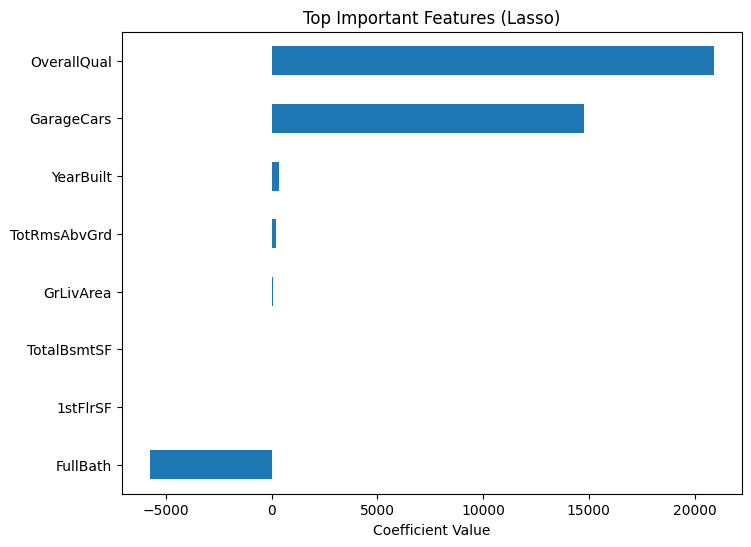

In [11]:
# Feature Importance Visualization
important_features = coefficients.sort_values().tail(15)

plt.figure(figsize=(8,6))

important_features.plot(kind="barh")

plt.title("Top Important Features (Lasso)")
plt.xlabel("Coefficient Value")

plt.show()

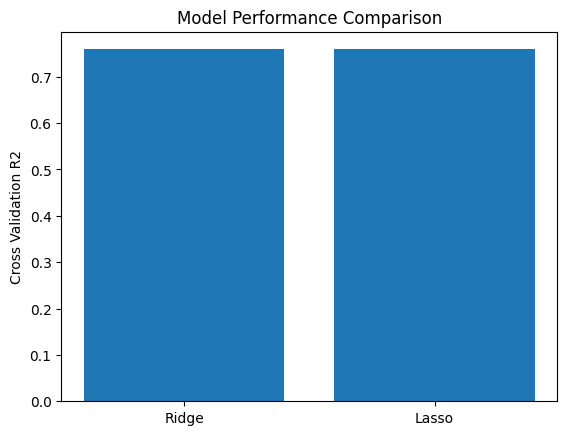

In [12]:
# Compare Models
models = ["Ridge","Lasso"]

scores = [
    ridge_scores.mean(),
    lasso_scores.mean()
]

plt.bar(models, scores)

plt.ylabel("Cross Validation R2")

plt.title("Model Performance Comparison")

plt.show()

## Key Insights

- Ridge regression reduces model variance using L2 regularization.
- Lasso regression performs feature selection by shrinking coefficients.
- Cross validation helps estimate model performance on unseen data.
- Lasso helps identify the most important features influencing house prices.